<a href="https://colab.research.google.com/github/MichelLLIUU/Hands-on-ML-with-Pytorch/blob/main/4_Training_a_model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

我们将了解多项式回归 ，这是一种更复杂的模型，可以适应非线性数据集。由于该模型比线性回归有更多参数，因此更容易过度拟合训练数据。我们将探讨如何利用学习曲线检测是否存在这种情况，然后我们将研究几种可以降低训练集过拟合风险的正则化技术。

最后，我们还将研究两种常用于分类任务的模型：逻辑回归和软最大回归。

**警告**
本章将使用线性代数和微积分的基本概念给出大量数学公式。要理解这些方程，你需要熟悉向量和矩阵--如何对它们进行转置、相乘和反转--以及偏导数。如果不熟悉这些概念，请查看在线补充材料中提供的线性代数和微积分入门 Jupyter 笔记本。如果你真的对数学过敏，你可以直接跳过方程；课文仍然可以帮助你掌握大部分概念。尽管如此，学习数学形式主义还是非常有用的，因为它可以让你阅读 ML 论文。本章包含的代码可以帮助你理解方程。

注释
在机器学习中，向量通常用列向量表示， ，列向量是具有单列的二维数组。如果θ和x都是列向量，那么预测结果为
𝛉
其中
𝛉
是θ的转置（行向量而不是列向量），而
𝛉
是
𝛉
和x 的矩阵乘法。当然，这也是同样的预测，只是现在用单格矩阵而不是标量值来表示。在本书中，我将使用这种符号，以避免在点乘和矩阵乘法之间切换。

警告
学习算法在训练过程中优化的损失函数往往与用于评估最终模型的性能指标不同。这通常是因为该函数更容易优化，和/或因为它有一些仅在训练期间需要的额外项（如正则化）。好的性能指标应尽可能接近最终业务目标。好的训练损耗易于优化，且与指标密切相关。例如，分类器通常使用对数损失等成本函数 进行训练（本章稍后将介绍），但使用精度/召回率进行评估。对数损失很容易最小化，这样做通常会提高精度/召回率。

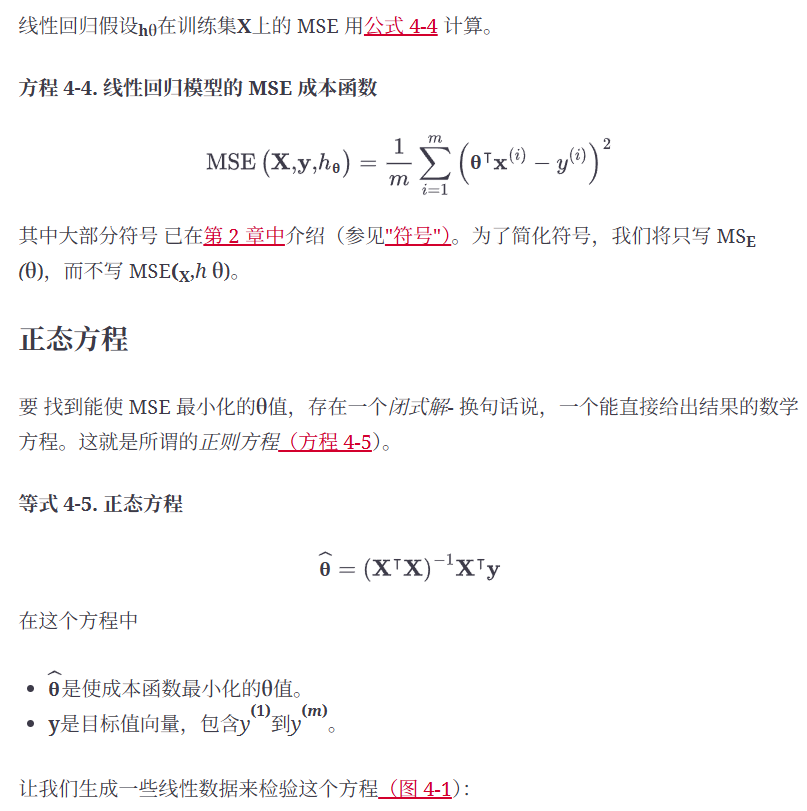

In [1]:
import numpy as np

rng = np.random.default_rng(seed=42)
m = 200  # number of instances
X = 2 * rng.random((m, 1))  # column vector
y = 4 + 3 * X + rng.standard_normal((m, 1))  # column vector

现在让我们计算
𝛉
。我们将使用 NumPy 线性代数模块中的inv() 函数 (np.linalg) 计算矩阵的逆，并使用@ 运算符进行矩阵乘法运算：

In [2]:
from sklearn.preprocessing import add_dummy_feature

X_b = add_dummy_feature(X)  # add x0 = 1 to each instance
theta_best = np.linalg.inv(X_b.T @ X_b) @ X_b.T @ y

注
@ 运算符 执行矩阵乘法。如果A 和B 是 NumPy 数组，那么A @ B 相当于np.matmul(A, B) 。许多其他库，如 TensorFlow、PyTorch 和 JAX，也支持@ 运算符。但是，您不能在纯 Python 数组（即列表的列表）上使用@ 。

In [3]:
theta_best

array([[3.69084138],
       [3.32960458]])

我们本希望θ0= 4 和θ1= 3，而不是θ0= 3.6908 和θ1= 3.3296。虽然很接近，但由于噪声的存在，无法恢复原始函数的精确参数。数据集越小，噪声越大，就越难恢复。

现在我们可以使用
𝛉
:

In [4]:
X_new = np.array([[0], [2]])
X_new_b = add_dummy_feature(X_new)  # add x0 = 1 to each instance
y_predict = X_new_b @ theta_best
y_predict

array([[ 3.69084138],
       [10.35005055]])

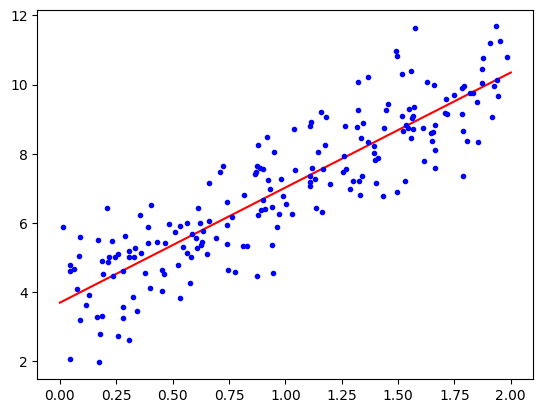

In [5]:
import matplotlib.pyplot as plt

plt.plot(X_new, y_predict, "r-", label="Predictions")
plt.plot(X, y, "b.")

plt.show()

In [6]:
from sklearn.linear_model import LinearRegression
lin_reg = LinearRegression()
lin_reg.fit(X, y)
lin_reg.intercept_, lin_reg.coef_

(array([3.69084138]), array([[3.32960458]]))

In [7]:
lin_reg.predict(X_new)

array([[ 3.69084138],
       [10.35005055]])

但是正则方程的计算复杂性很高O(N^2)，所以对于大规模数据集训练太吃力。

现在我们来看看训练线性回归模型的一种截然不同的方法，这种方法更适用于有大量特征或有太多训练实例而内存无法容纳的情况。

# 梯度下降法
梯度下降 是一种通用优化算法，能够为各种问题找到最优解。梯度下降算法的总体思路是迭代调整参数，以最小化成本函数。

假设你迷失在浓雾弥漫的山中，只能感觉到脚下地面的坡度。要想快速到达谷底，一个好的策略就是沿着坡度最陡的方向下山。这正是梯度下降法的作用：它测量误差函数相对于参数向量 θ 的局部梯度，并沿着梯度下降的方向 Go。一旦梯度为零，就达到了最小值！

在实践中，一开始可以用随机值填充θ（这叫做随机初始化）。 然后逐步改进，每次迈出一小步，每一步都试图降低代价函数 （如 MSE），直到算法收敛到最小值（见图 4-3）。

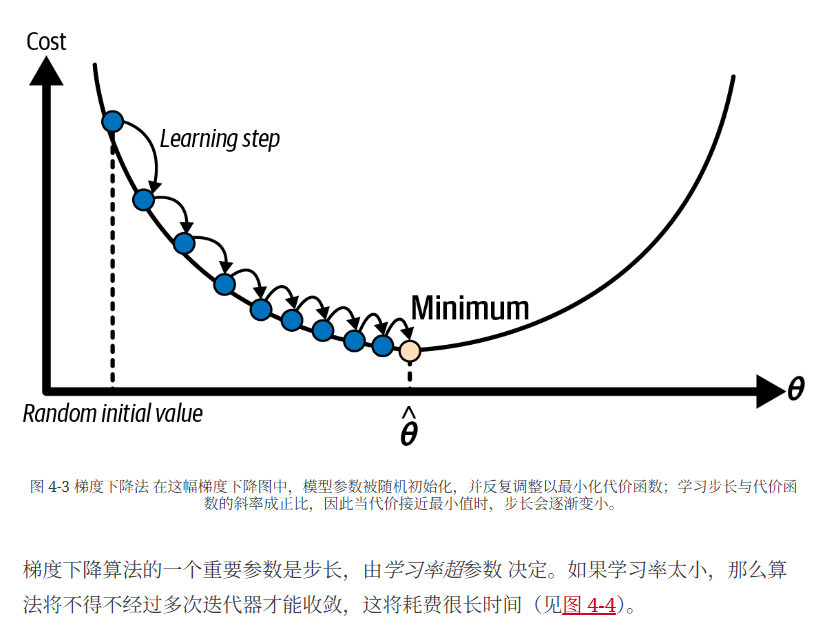

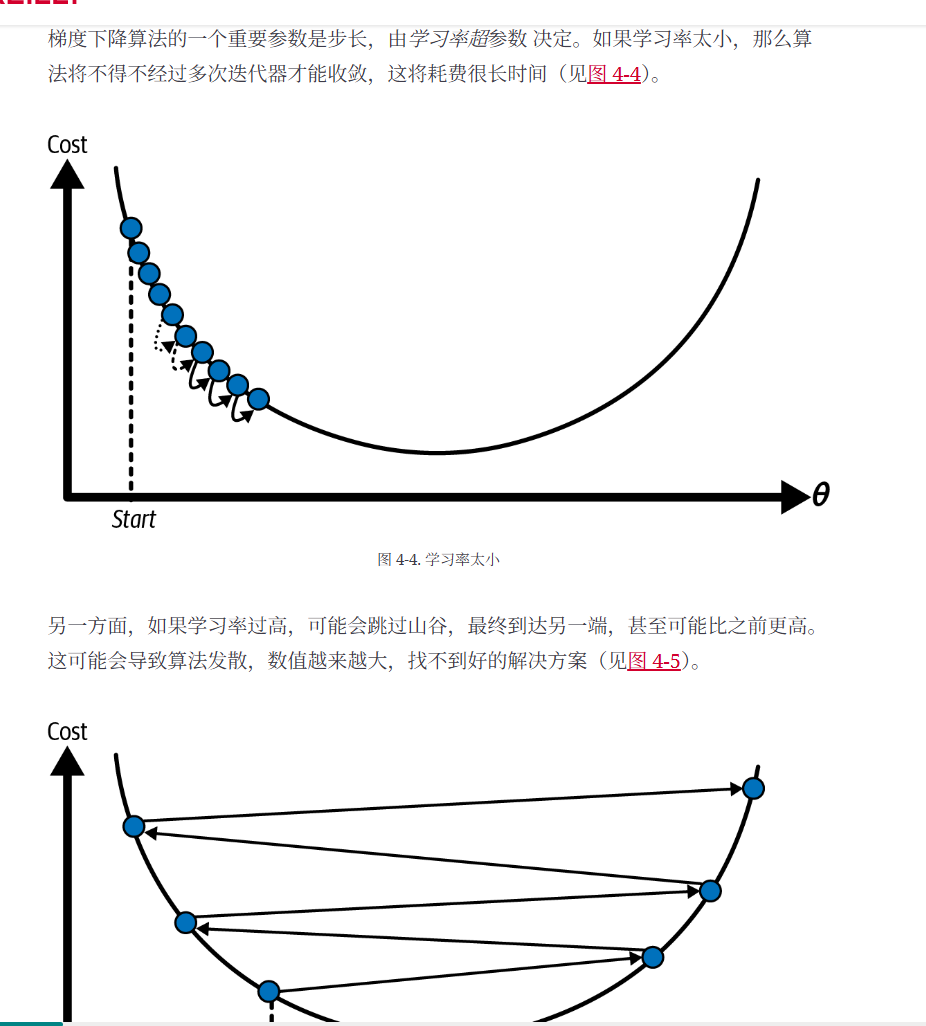

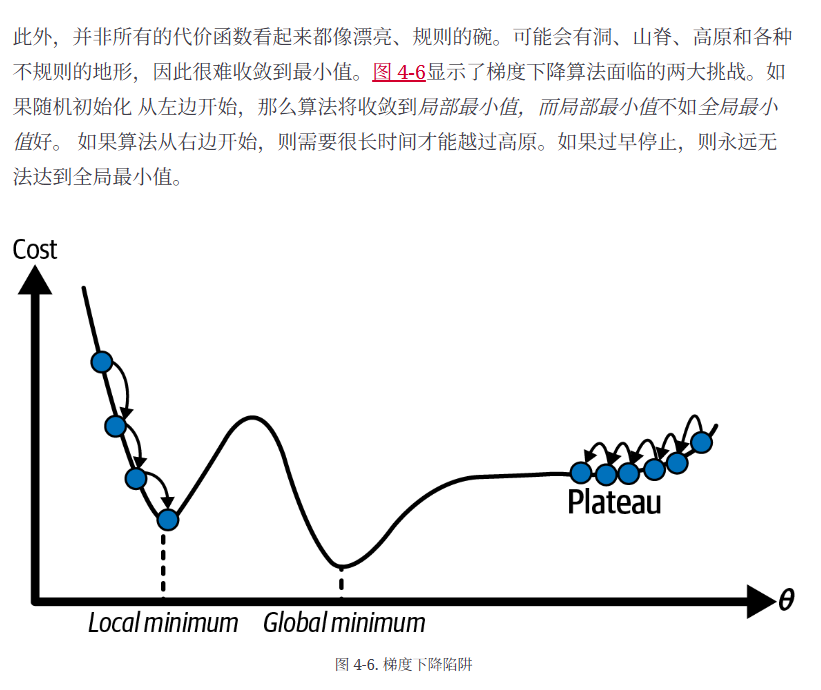

幸运的是，**线性回归模型的 MSE 成本函数恰好是一个凸函数**， ，这意味着如果在曲线上任意选取两点，连接它们的线段永远不会低于曲线。这意味着不存在局部最小值，只有一个全局最小值。此外，它还是一个连续函数，斜率永远不会突然变化。2这两个事实有一个很好的结果：梯度下降法可以保证任意接近全局最小值（如果等待的时间足够长，而且学习率不是太高的话）。

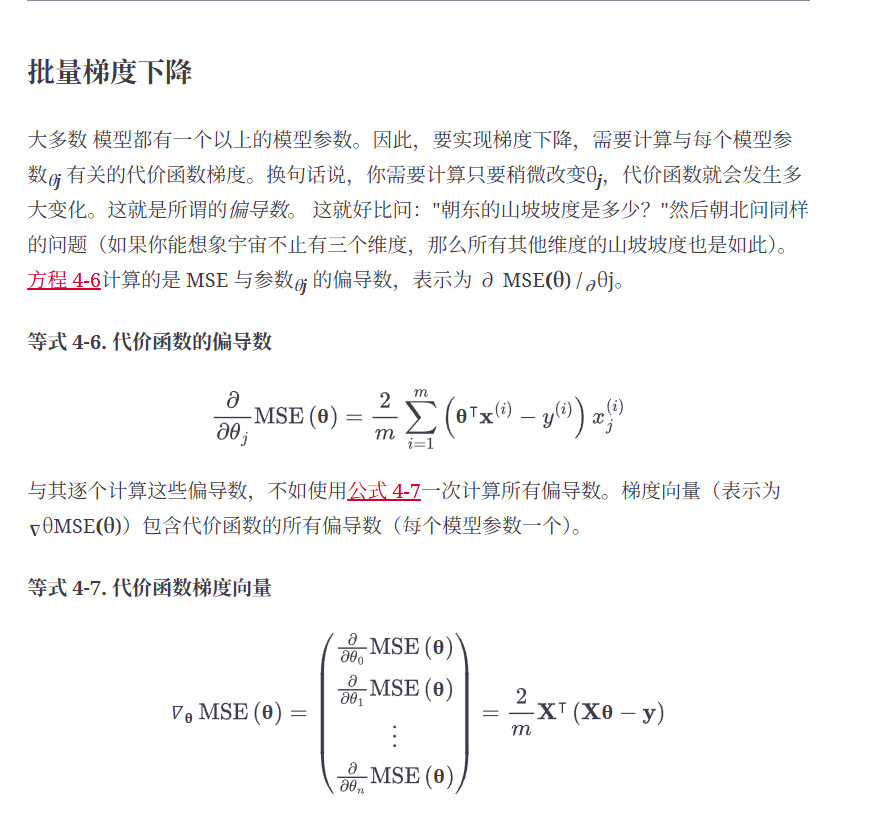

警告
请注意，这个公式涉及到每一步梯度下降时对整个训练集X 的计算！这就是为什么该算法被称为批量梯度下降算法：它在每一步都使用整批训练数据（实际上，全梯度下降 可能是一个更好的名字）。因此，在非常大的训练集上，梯度下降算法的速度非常慢（我们稍后会介绍一些速度更快的梯度下降算法）。不过，梯度下降算法能很好地与特征数量相匹配；当特征数量达到数十万时，使用梯度下降算法训练线性回归模型要比使用正态方程或 SVD 分解快得多。

有了指向上坡的梯度向量后，只要反方向走就可以下坡。这意味着要从θ中减去∇θMSE(θ)。4将梯度向量乘以η，以确定下坡步长（公式 4-8）。

等式 4-8. 梯度下降步骤
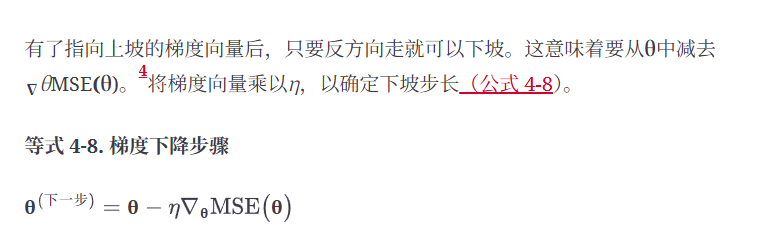

In [ ]:
eta = 0.1  # learning rate
n_epochs = 1000
m = len(X_b)  # number of instances

rng = np.random.default_rng(seed=42)
theta = rng.standard_normal((2, 1))  # randomly initialized model parameters

for epoch in range(n_epochs):
    gradients = 2 / m * X_b.T @ (X_b @ theta - y)
    theta = theta - eta * gradients

In [ ]:
theta

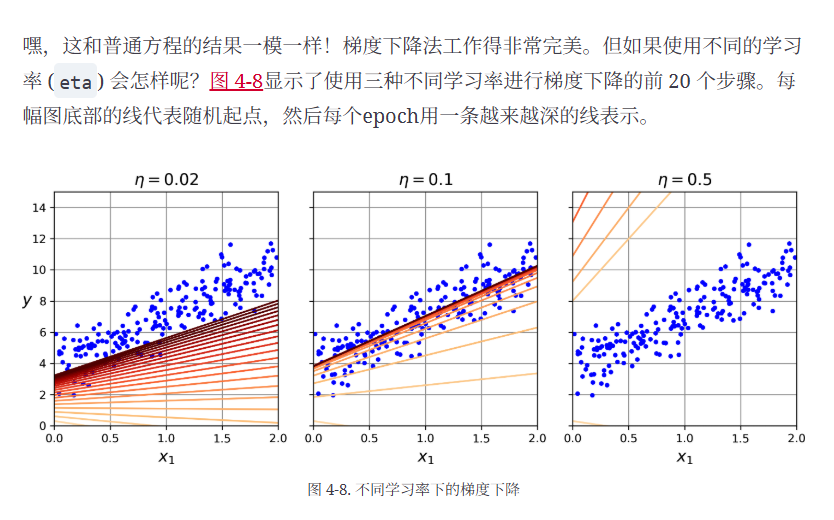

左图中，学习率过低：算法最终会到达解，但需要很长时间。在中间，学习率看起来相当不错：仅仅几个历元，它就已经收敛到了解决方案。右图中，学习率过高：算法发散，到处跳跃，实际上每一步都离解决方案越来越远。

要找到一个好的学习率，可以使用网格搜索（参见第 2 章）。但是，您可能希望限制epoch的数量 ，这样网格搜索就可以剔除收敛时间过长的模型。

您可能想知道如何设置历元数。如果epoch次数太少，算法停止时离最优解仍然很远；但如果epoch次数太多，当模型参数 不再变化时，就会浪费时间。一个简单的解决方法是，设置一个非常大的历时数，但当梯度向量变得很小时，即当梯度向量的法线小于一个很小的数**ε（称为容差）**时，就中断算法--，因为这发生在梯度下降（几乎）达到最小值的时候。

# 随机梯度下降
批量梯度下降法的主要问题在于，它每一步都要使用整个训练集来计算梯度，因此当训练集很大时，计算速度会非常慢。与之相反的是，随机梯度下降法每一步都会在训练集中随机挑选一个实例，然后只根据该单一实例计算梯度。显然，每次只处理一个实例会使算法的速度大大提高，因为每次迭代时需要处理的数据非常少。由于每次迭代时内存中只需要一个实例，这也使得在庞大的训练集上进行训练成为可能（随机 GD 可以作为外核算法实现；参见第 1 章）。

另一方面，由于其随机（即随机）性质，该算法的规律性远低于批量梯度下降算法：代价函数不是平缓下降直至达到最小值，而是上下跳动，仅在平均值上下降。随着时间的推移，代价函数最终会非常接近最小值，但一旦达到最小值，代价函数就会继续反弹，永远不会稳定下来（见图 4-9）。一旦算法停止，最终的参数值将是好的，但不是最优的。

当代价函数 非常不规则时（如图 4-6），这实际上有助于算法跳出局部最小值，因此随机梯度下降算法比批量梯度下降算法更有机会找到全局最小值。

因此，随机性有利于摆脱局部最优，但也有坏处，因为这意味着算法永远无法在最小值处稳定下来。解决这一难题的方法之一是逐渐降低学习率。开始时步数较大（这有助于快速取得进展并摆脱局部极小值），然后步数越来越小，从而让算法在全局极小值处稳定下来。这个过程类似于模拟退火， ，这种算法的灵感来自冶金学中的退火过程，即熔融金属缓慢冷却的过程。决定每次迭代的学习率的函数称为学习进度表。 如果学习率 降低得太快，可能会陷入局部最小值，甚至在到达最小值的中途被冻结。如果学习速度减得太慢，可能会在最小值附近跳动很长时间，如果过早停止训练，最终会得到一个次优解。

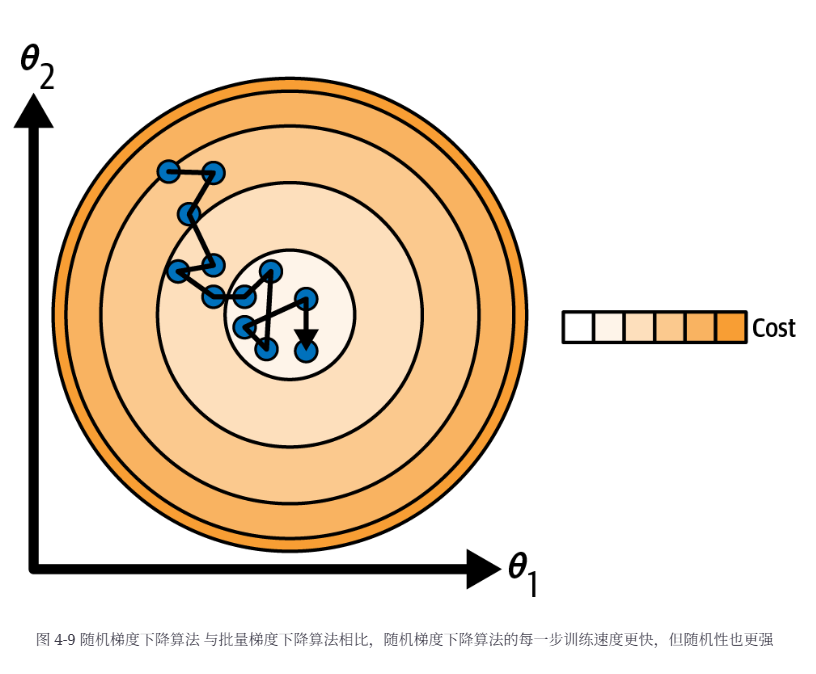

In [ ]:
n_epochs = 50
t0, t1 = 5, 50  # learning schedule hyperparameters

def learning_schedule(t):
    return t0 / (t + t1)

rng = np.random.default_rng(seed=42)
theta = rng.standard_normal((2, 1))  # randomly initialized model parameters

for epoch in range(n_epochs):
    for iteration in range(m):
        random_index = rng.integers(m)
        xi = X_b[random_index : random_index + 1]
        yi = y[random_index : random_index + 1]
        gradients = 2 * xi.T @ (xi @ theta - yi)  # for SGD, do not divide by m
        eta = learning_schedule(epoch * m + iteration)
        theta = theta - eta * gradients

In [ ]:
theta

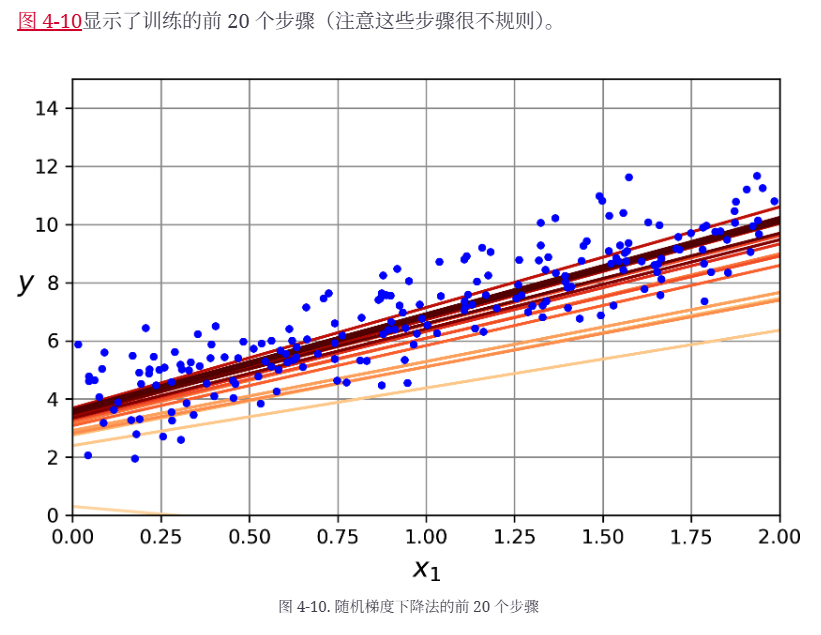

需要注意的是，由于实例是随机抽取的，因此有些实例可能会在每个历元中被抽取多次，而有些实例则可能根本不会被抽取。如果你想确保算法在每个epoch都会选取每个实例，另一种方法是对训练集进行洗牌（确保输入特征和标签共同洗牌），然后逐个实例进行训练，然后再次洗牌，以此类推。不过，这种方法比较复杂，而且一般不会改善结果。

警告
使用随机梯度下降法时，训练实例必须是独立且同分布（IID）的，以确保参数平均趋向全局最优。确保这一点的简单方法是在训练过程中对实例进行洗牌（例如，随机挑选每个实例，或在每个历元开始时对训练集进行洗牌 ）。如果不对实例进行洗牌--例如，如果实例是按标签排序的，那么 SGD 会先对一个标签进行优化，然后再对下一个标签进行优化，以此类推，这样就不会接近全局最小值。

要在 Scikit-Learn 中使用随机广东十一选五进行线性回归 ，可以使用SGDRegressor 类，该类默认优化 MSE 成本函数。以下代码最多运行 1,000 个 epoch (max_iter) 或在 100 个 epoch (n_iter_no_change) 期间运行到损失下降小于10-5(tol) 为止。开始时的学习率为 0.01 (eta0) ，使用默认的学习计划（与我们使用的不同）。最后，它没有使用任何正则化 (penalty=None ；稍后会有更多详情) ：

In [ ]:
from sklearn.linear_model import SGDRegressor

sgd_reg = SGDRegressor(max_iter=1000, tol=1e-5, penalty=None, eta0=0.01,
                       n_iter_no_change=100, random_state=42)
sgd_reg.fit(X, y.ravel())  # y.ravel() because fit() expects 1D targets

再一次，你找到的解与正则方程返回的解非常接近：

In [ ]:
sgd_reg.intercept_, sgd_reg.coef_

提示
所有 Scikit-Learn 估计器都可以使用fit() 方法 进行训练，但有些估计器也有partial_fit() 方法，您可以调用该方法对一个或多个实例进行单轮训练（它忽略max_iter 或tol 等超参数）。重复调用partial_fit() 将逐步训练模型。这在需要对训练过程进行更多控制时非常有用。其他模型有一个warm_start 超参数（有些模型两个超参数都有）：如果设置了warm_start=True ，在训练好的模型上调用fit() 方法将不会重置模型；它只是在原处继续训练，尊重max_iter 和tol 等超参数。请注意，fit() 会重置学习计划使用的迭代计数器，而partial_fit() 不会。

# 小批量梯度下降算法
最后一种梯度下降算法叫做迷你批量梯度下降算法。只要你了解批量和随机梯度下降算法，就会发现它非常简单：在每一步中，迷你批量梯度下降算法不是基于全部训练集（如批量梯度下降算法），也不是基于一个实例（如随机梯度下降算法）计算梯度，而是基于称为迷你批量的小随机实例集计算梯度。**与随机 GD 相比，迷你批量 GD 的主要优势在于可以通过硬件加速矩阵运算来提高性能，尤其是在使用图形处理器(GPU) 时。**

与随机 GD 相比，算法在参数空间 中的进展不那么不稳定，尤其是在相当大的迷你批次中。因此，与随机 GD 相比，迷你批量 GD 最终会更接近最小值，但可能更难摆脱局部最小值（对于存在局部最小值的问题，与使用 MSE 成本函数的线性回归不同）。图 4-11显示了三种梯度下降算法在参数空间中的训练路径。它们的最终结果都接近最小值，但批量 GD 的路径实际上在最小值处停止，而随机 GD 和迷你批量 GD 都在继续走动。不过，别忘了批量 GD 每走一步都要花费大量时间，而如果使用良好的学习计划，随机 GD 和迷你批量 GD 也会到达最小值。

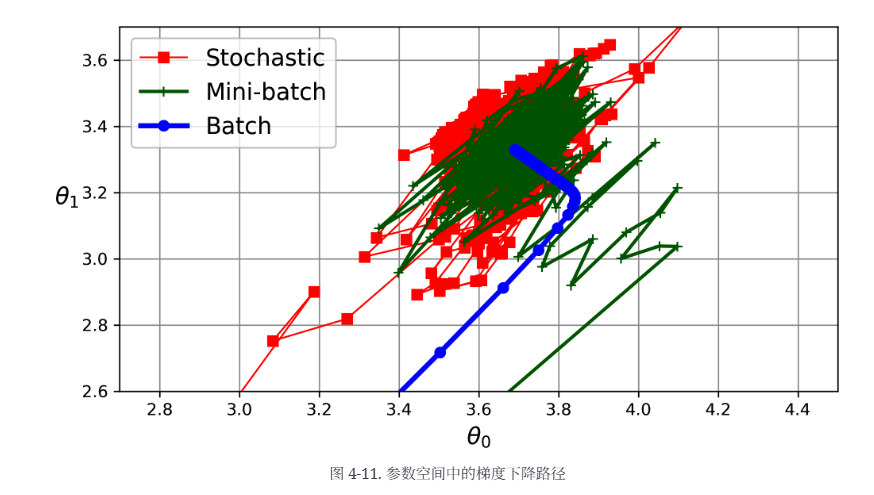

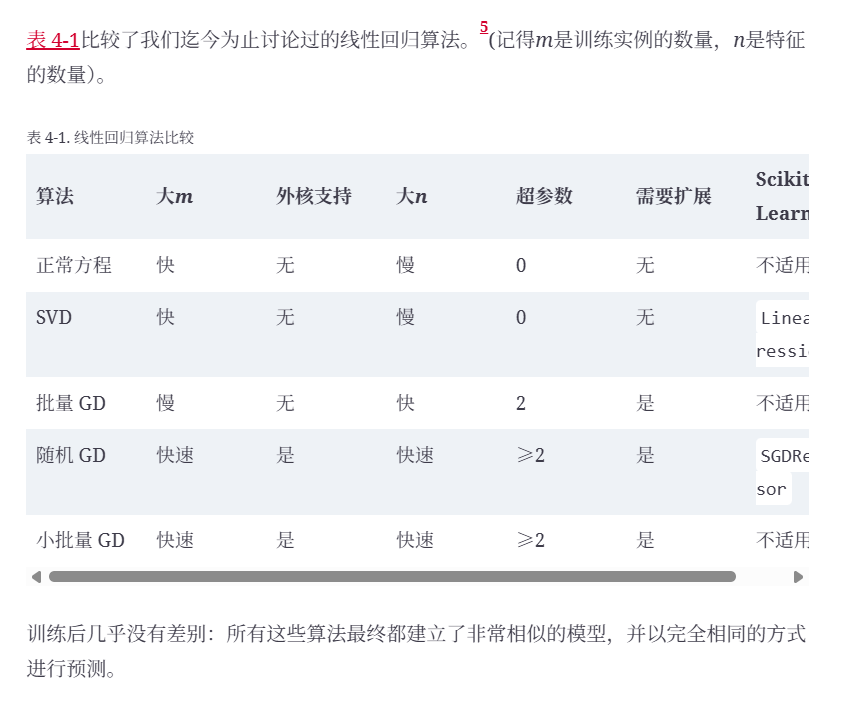